In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))
from config import DATA_DATASET

In [18]:
pddf = pd.read_csv(DATA_DATASET / "vessel_weekly_features.csv")

pddf.value_counts("ship_type")

ship_type
Cargo        34178
Tanker       13281
Passenger     5443
Tug           3717
Fishing       2653
Name: count, dtype: int64

In [19]:
# Feature groups — each will become one figure with a grid of boxplots
selected_features = [
    "mean_moving_speed",
    "sog_p10",
    "sog_median",
    "sog_p90",
    "frac_time_slow",
    "frac_time_fast",
    "rot_mean_abs",
    "rot_std",
    "heading_cog_diff_mean",
    "fishing_ratio",
    "anchor_ratio",
    "underway_engine_ratio",
    "moored_ratio",
    "length",
    "width",
    "max_draught",
    "draught_variability",
    "length_beam_ratio",
    "draught_length_ratio",
    "bbox_area",
    "n_pings",
    "mean_ping_interval_seconds",
]

feature_groups = {
    "Speed Profile": [
        "mean_moving_speed",
        "max_speed",
        "std_speed",
        "sog_p10",
        "sog_median",
        "sog_p90",
        "frac_time_slow",
        "frac_time_fast",
        "sog_bimodality",
    ],
    "Course & Heading": [
        "cog_variability",
        "rot_mean_abs",
        "rot_std",
        "heading_cog_diff_mean",
    ],
    "Navigational Status": [
        "fishing_ratio",
        "anchor_ratio",
        "underway_engine_ratio",
        "moored_ratio",
        "n_nav_statuses",
    ],
    "Physical Dimensions": [
        "length",
        "width",
        "max_draught",
        "min_draught",
        "draught_variability",
        "length_beam_ratio",
        "draught_length_ratio",
    ],
    "Spatial & Trajectory": [
        "lat_std",
        "lon_std",
        "bbox_area",
        "straightness_index",
    ],
    "Temporal & Ping": [
        "n_pings",
        "time_span_seconds",
        "mean_ping_interval_seconds",
    ],
    "Cargo Type": ["CargoX_ratio", "CargoY_ratio", "CargoZ_ratio", "CargoOS_ratio", "CargoReserved_ratio"],
}

In [20]:
df = pddf.copy()
df = df[feature_groups["Cargo Type"]]
df.value_counts()

CargoX_ratio  CargoY_ratio  CargoZ_ratio  CargoOS_ratio  CargoReserved_ratio
0.000000      0.000000      0.0           0.000000       0.0                    51947
1.000000      0.000000      0.0           0.000000       0.0                     2749
0.000000      0.000000      0.0           1.000000       0.0                     1165
              1.000000      0.0           0.000000       0.0                      913
              0.000000      0.0           0.000000       1.0                      739
                                                                                ...  
              0.682412      0.0           0.000000       0.0                        1
              0.932920      0.0           0.000000       0.0                        1
              0.970979      0.0           0.000000       0.0                        1
              0.368075      0.0           0.000000       0.0                        1
0.385817      0.000000      0.0           0.002218       0.0   

In [21]:
# pddf= pddf[pddf["ship_type"].isin([ "Fishing", "Tug", "Passenger"])]  # Filter for specific ship types
class_column = "ship_type"  # Replace with the actual column name for vessel class
palette = {
    "Cargo": "#1C08F300",  # purple
    "Tanker": "#055519",  # teal
    "Fishing": "#F1460C",  # coral
    "Tug": "#E015B4",  # blue
    "Passenger": "#0FEE1A",  # pink
}


def plot_feature_group(df, group_name: str, features: list[str]) -> None:
    # Only keep features that actually exist in the dataframe
    features = [f for f in features if f in df.columns]
    if not features:
        print(f"Skipping '{group_name}' — no matching columns found.")
        return

    n = len(features)
    ncols = 3
    nrows = (n + ncols - 1) // ncols  # ceiling division

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
    axes = axes.flatten()

    for i, feat in enumerate(features):
        ax = axes[i]
        sns.boxplot(
            data=df,
            x=class_column,
            hue=class_column,
            y=feat,
            palette=palette,
            order=list(palette.keys()),
            showfliers=False,  # hide outliers for readability; set True to show them
            linewidth=0.8,
            ax=ax,
        )
        ax.set_title(feat, fontsize=11)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(axis="x", rotation=25)

    # Hide any unused subplot slots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Feature distributions by ship type — {group_name}", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

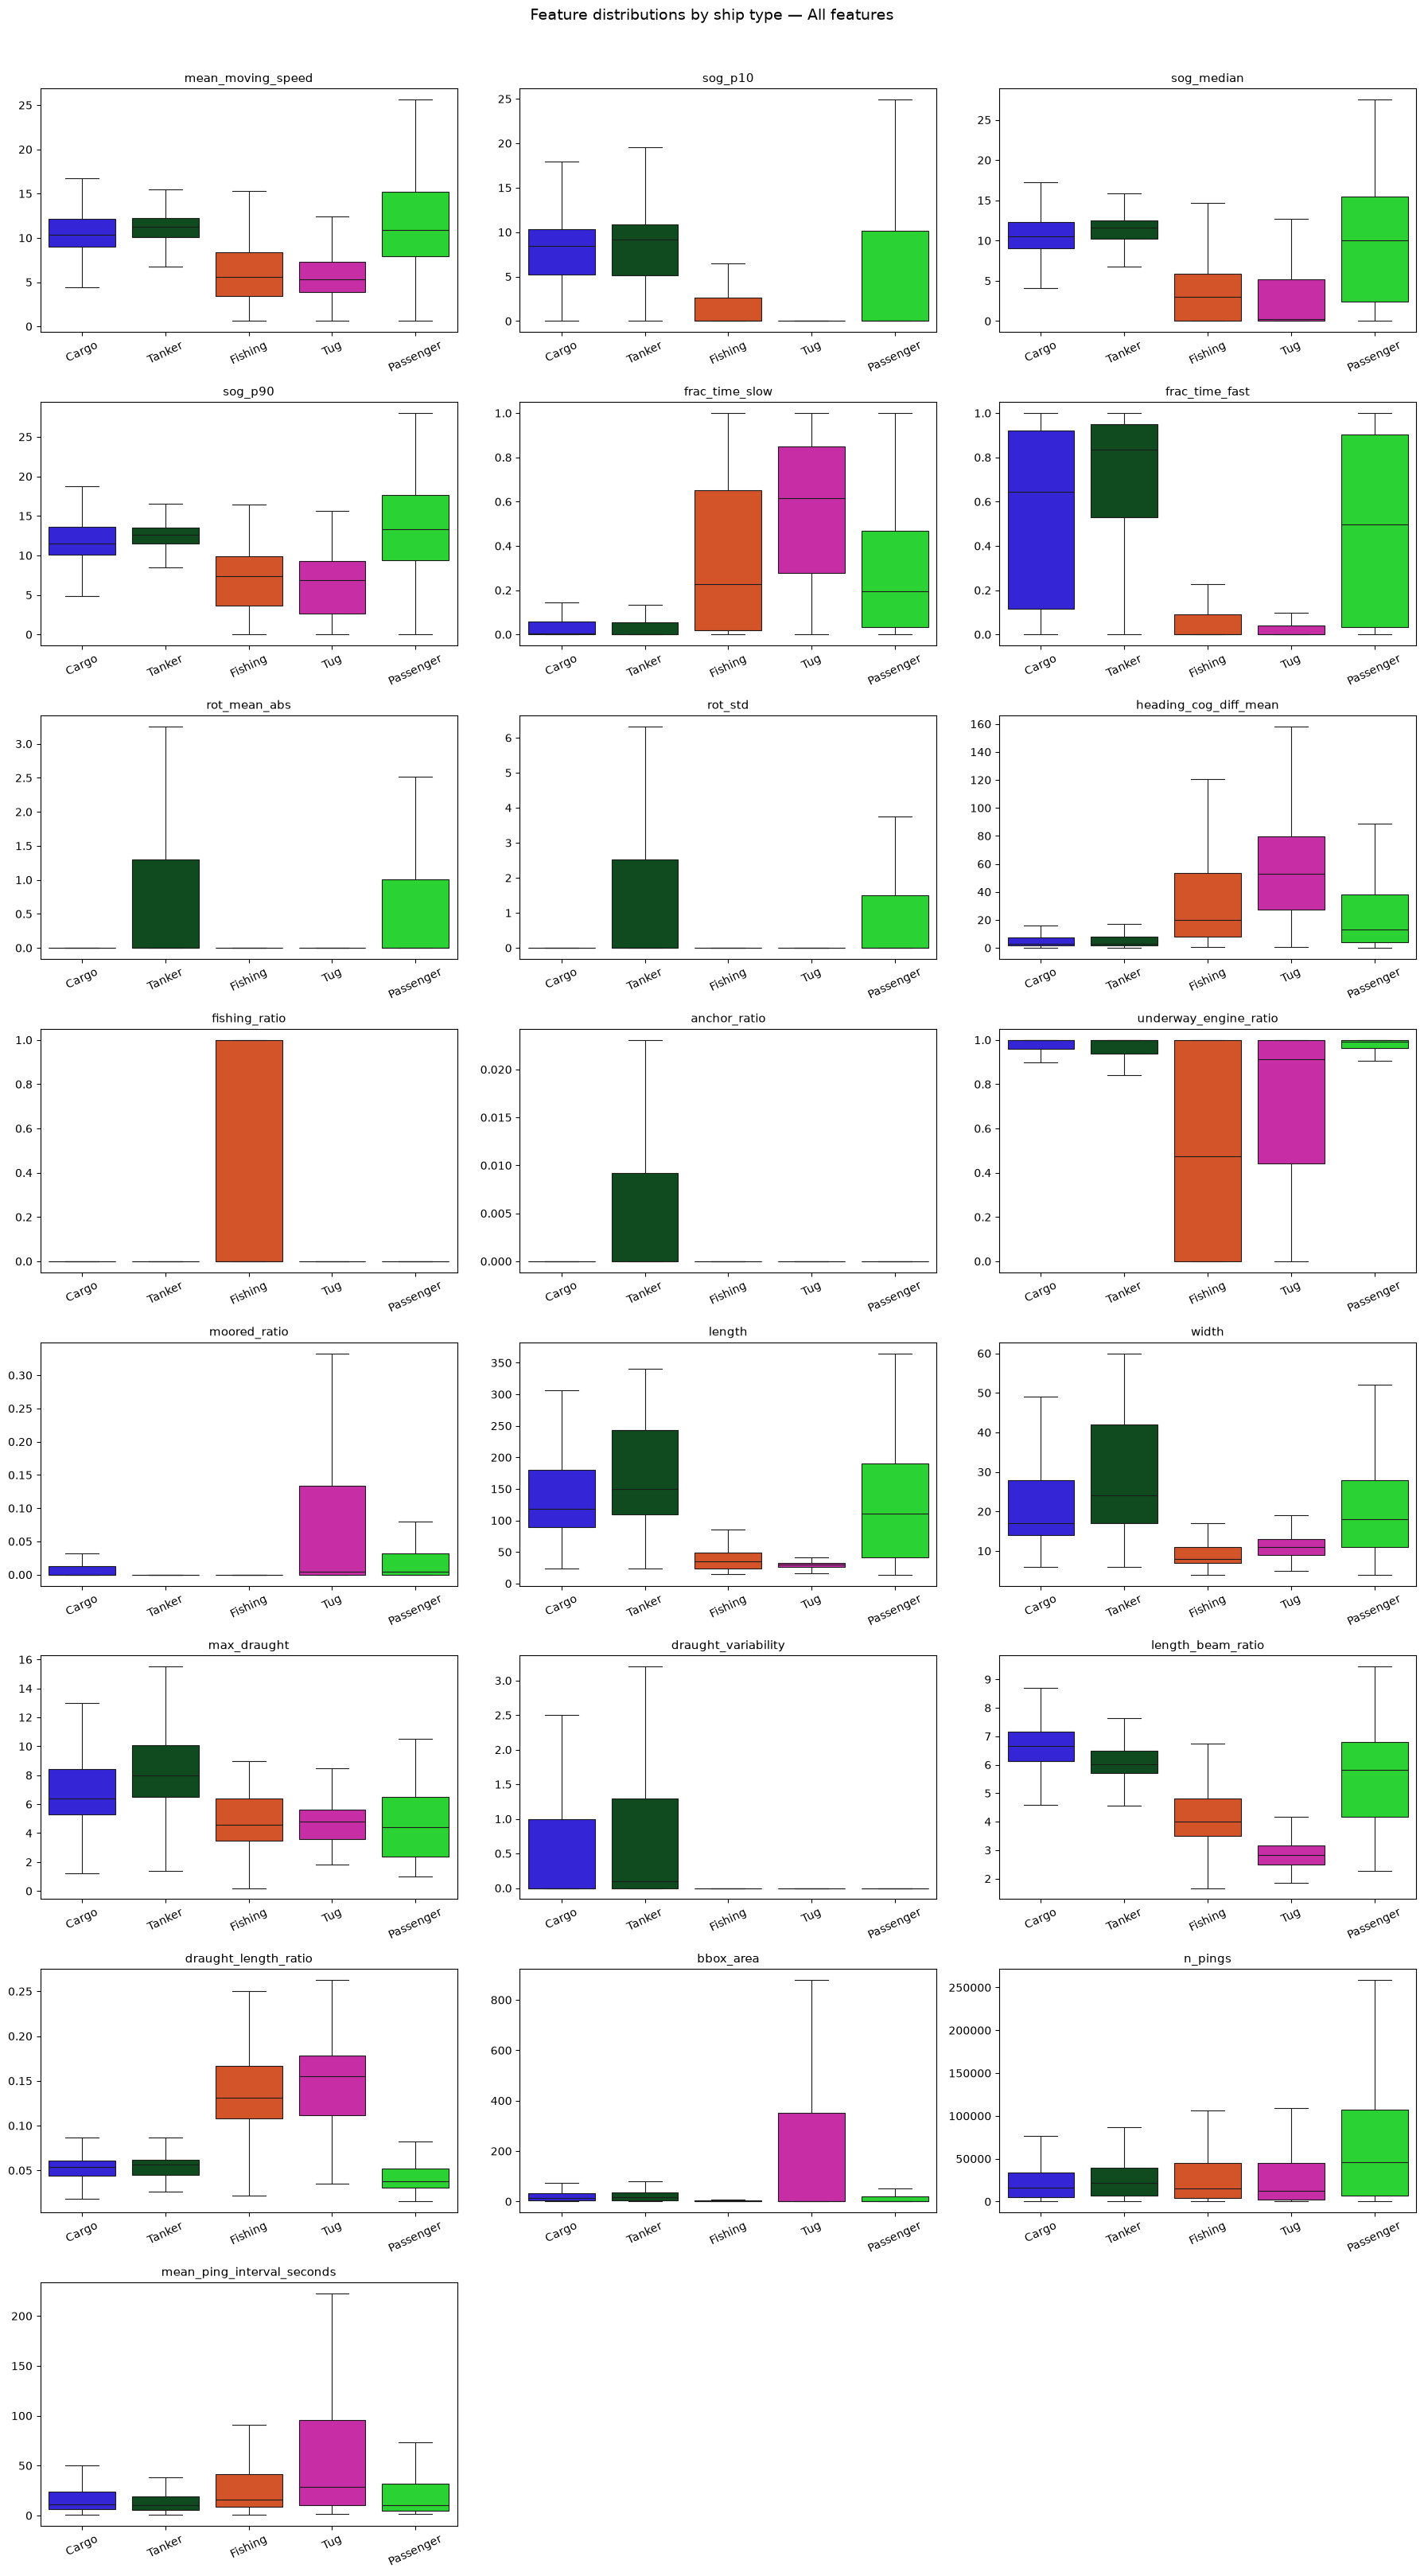

In [22]:
plot_feature_group(pddf, "All features", selected_features)

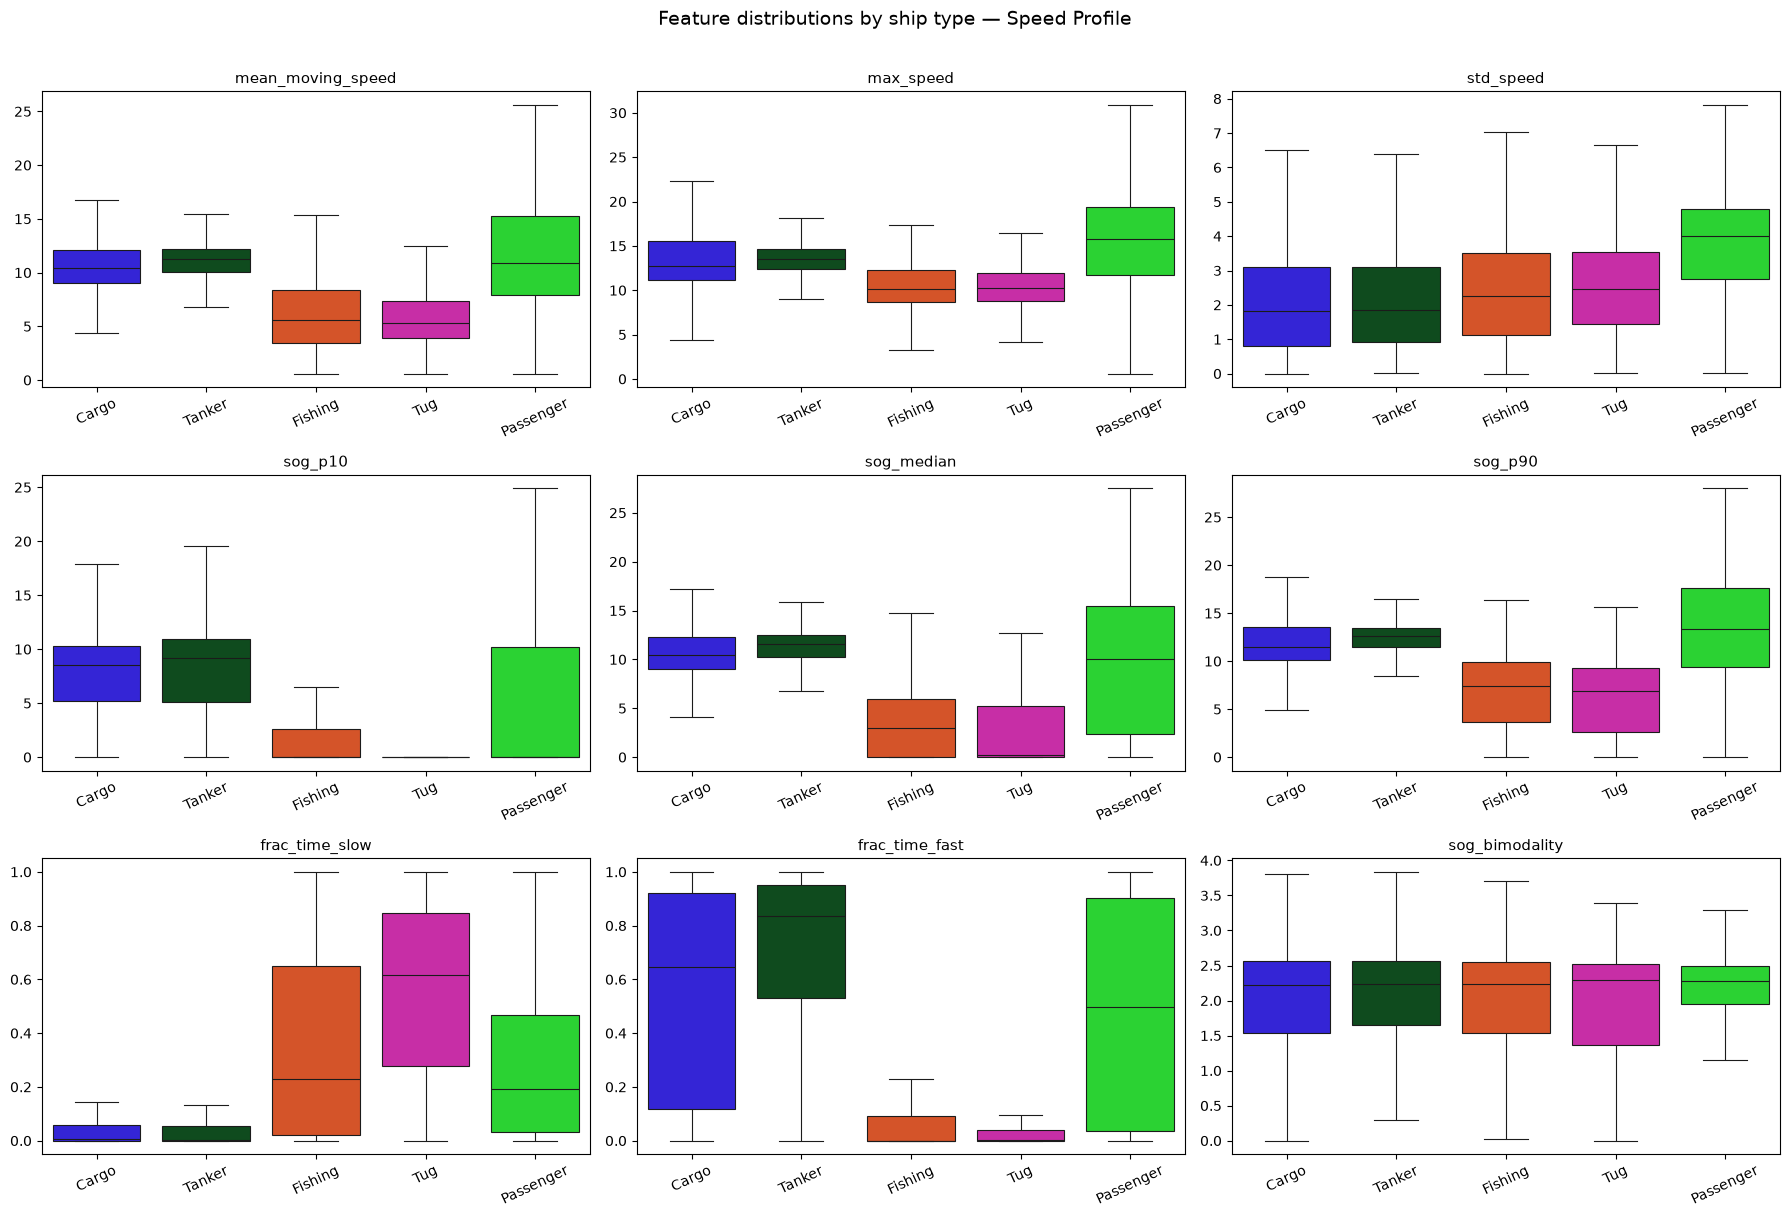

In [23]:
plot_feature_group(pddf, "Speed Profile", feature_groups["Speed Profile"])

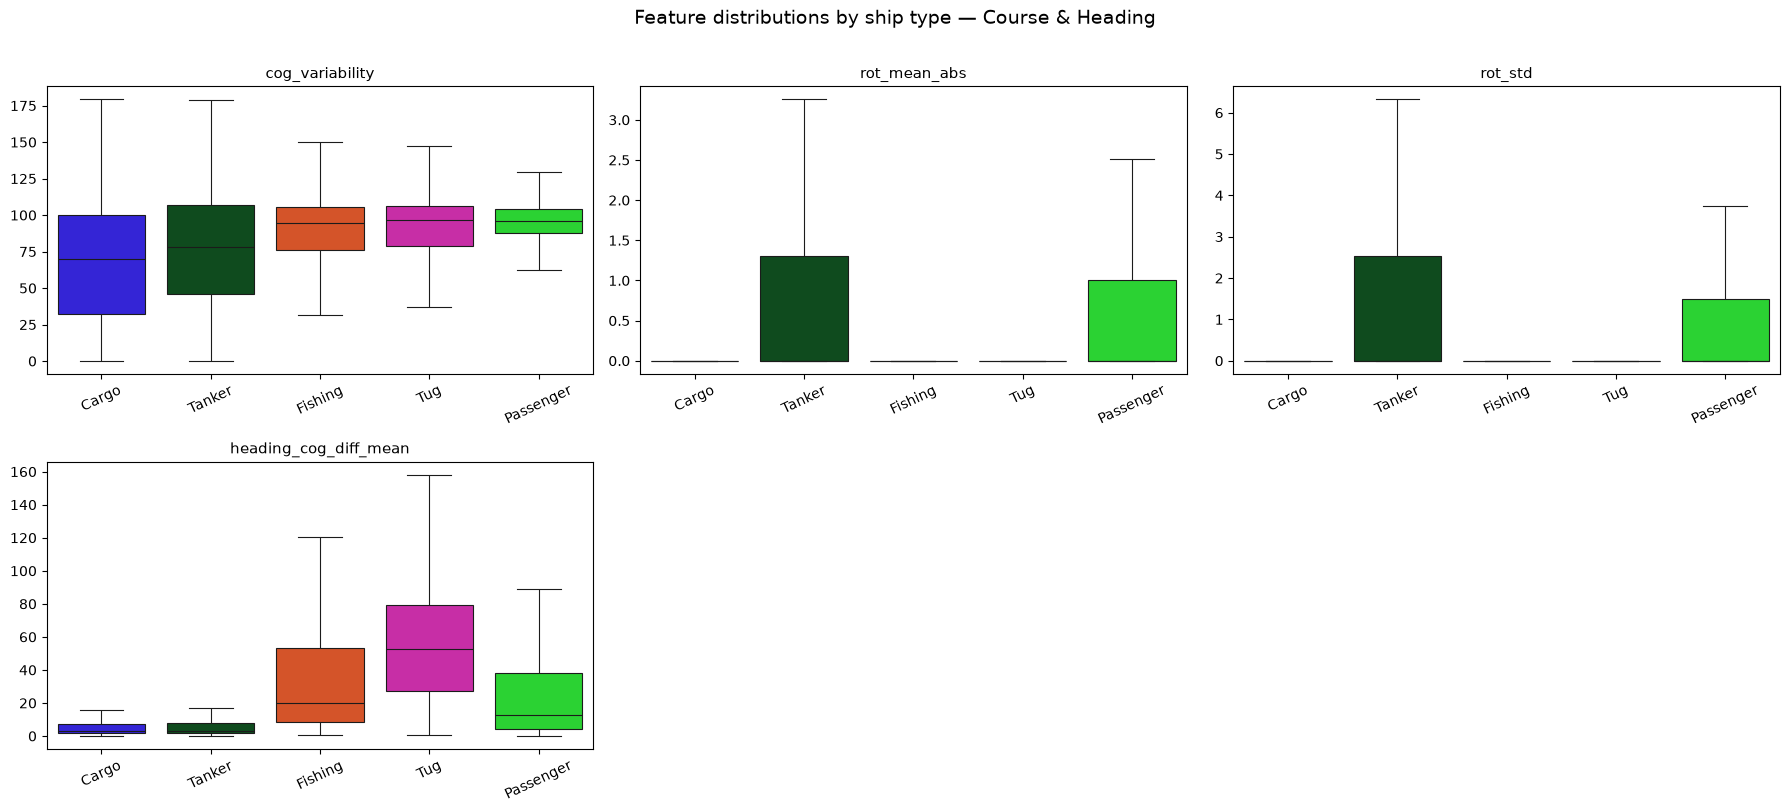

In [24]:
plot_feature_group(pddf, "Course & Heading", feature_groups["Course & Heading"])

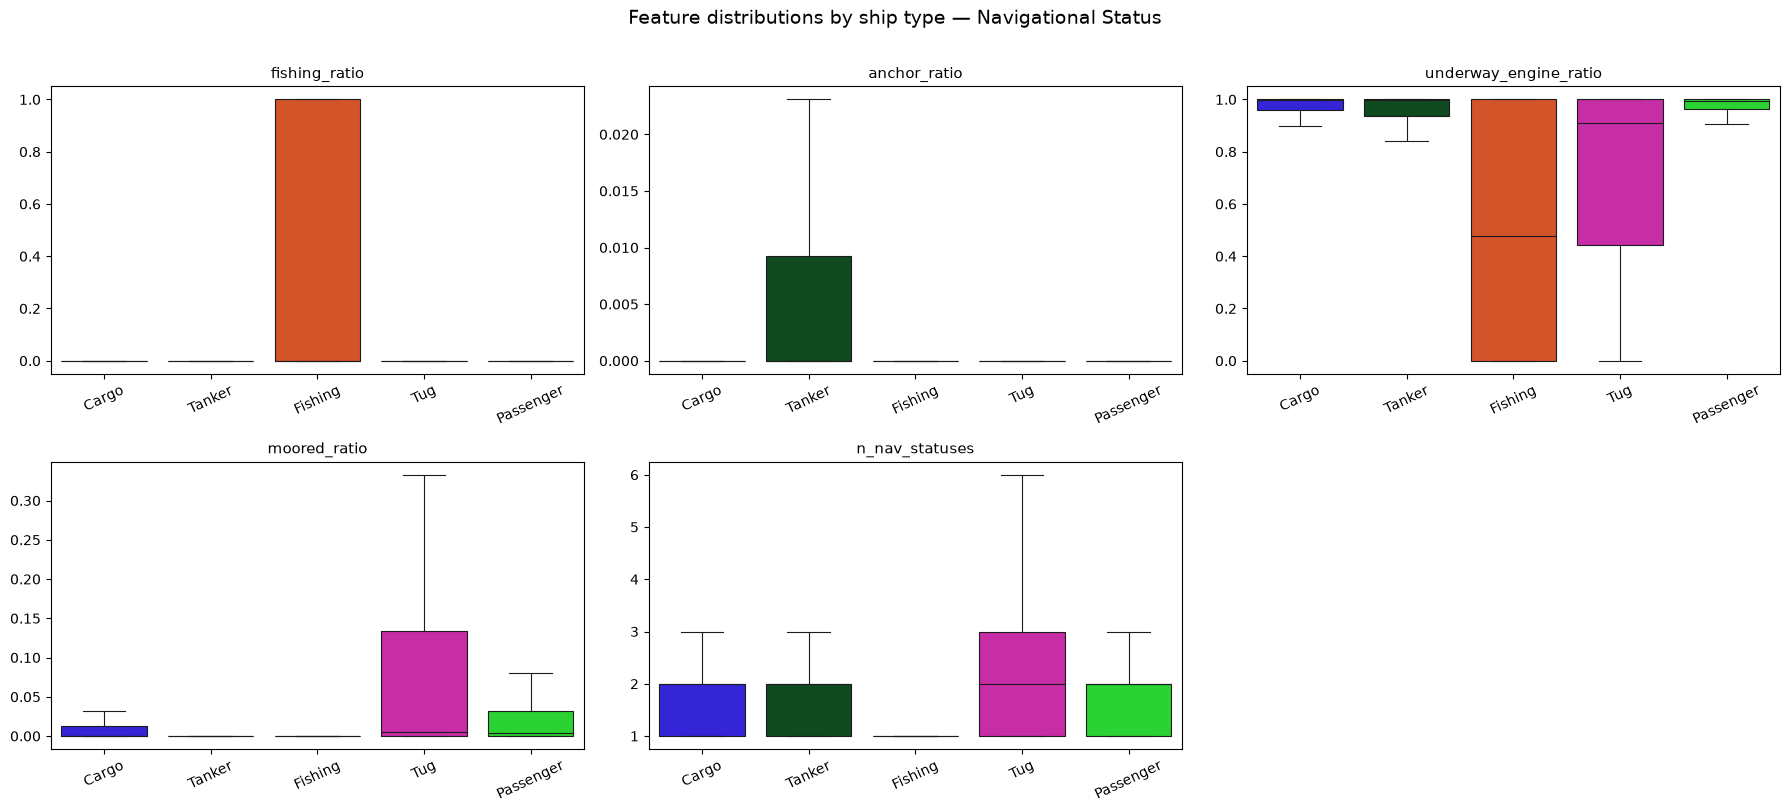

In [25]:
plot_feature_group(pddf, "Navigational Status", feature_groups["Navigational Status"])

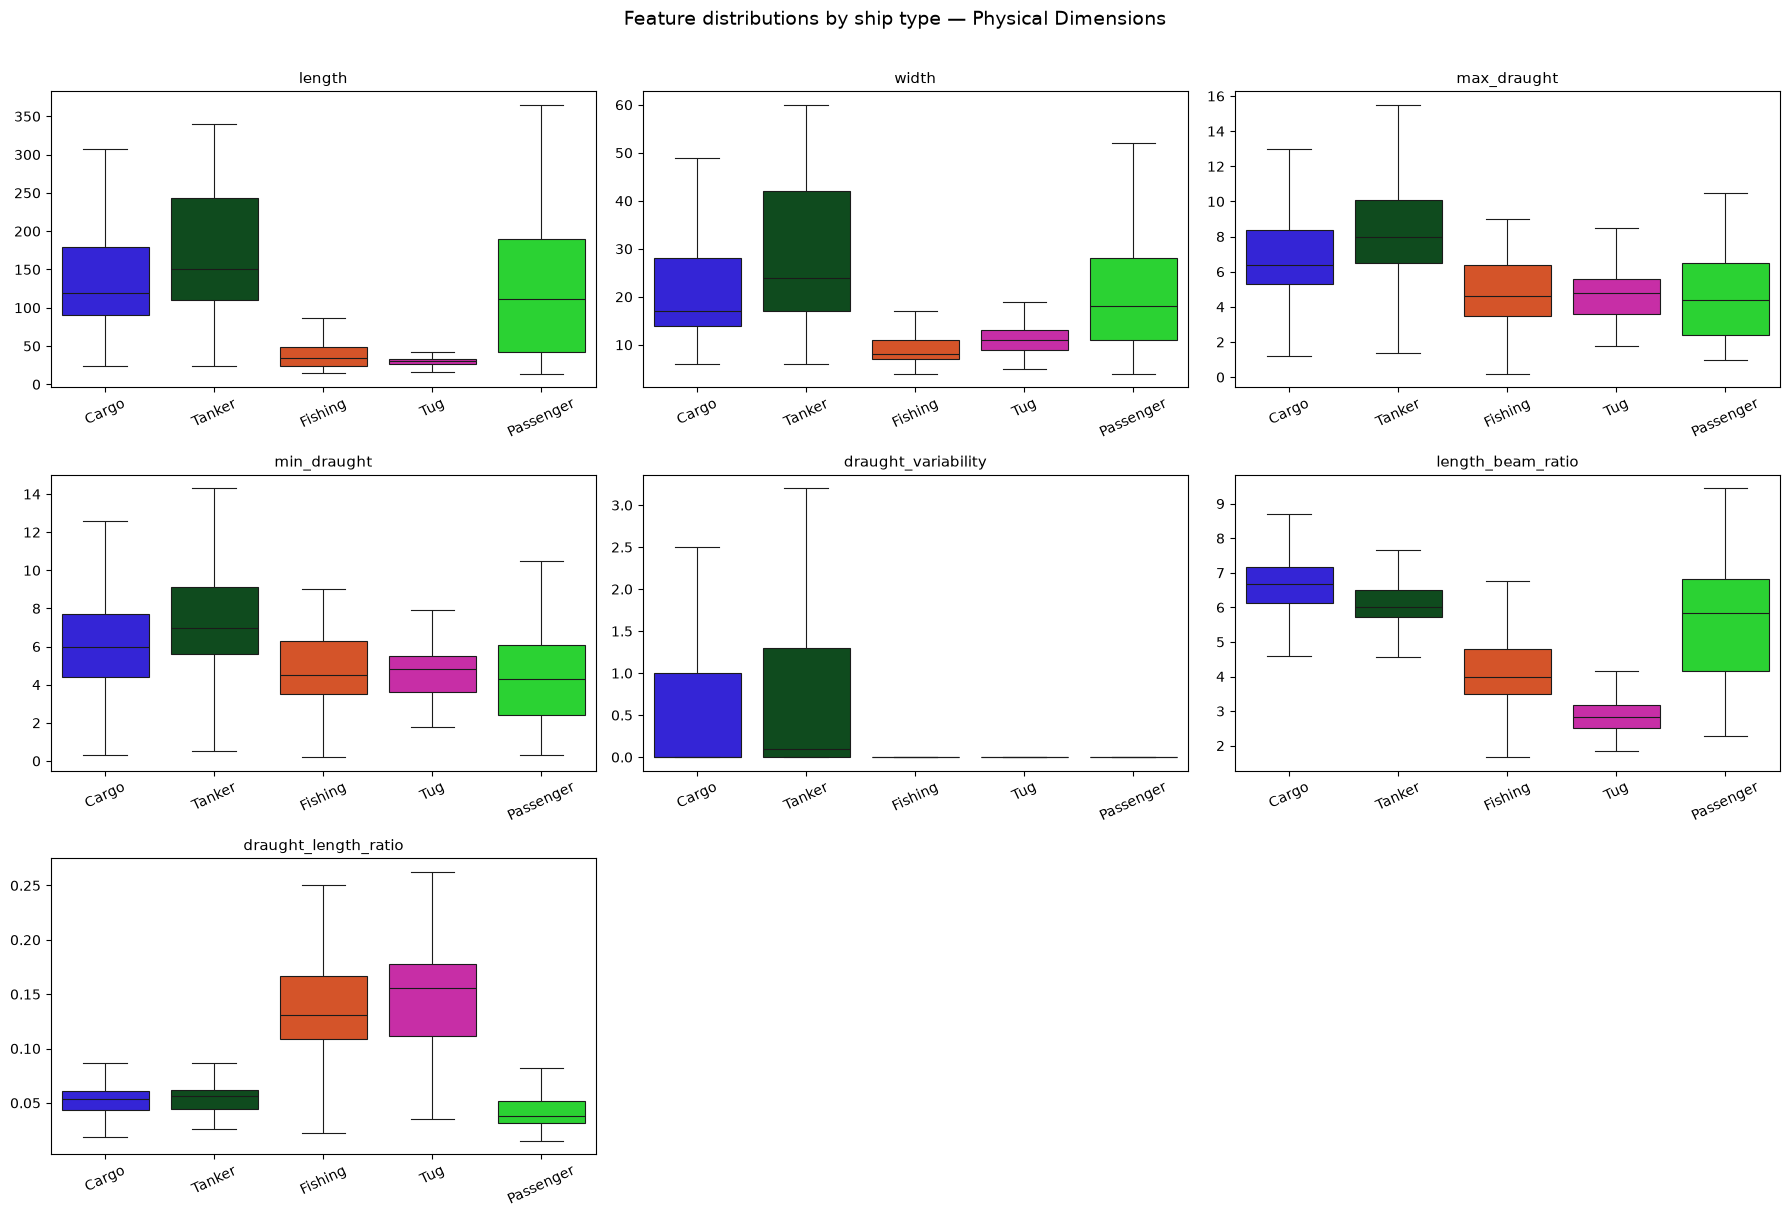

In [26]:
plot_feature_group(pddf, "Physical Dimensions", feature_groups["Physical Dimensions"])

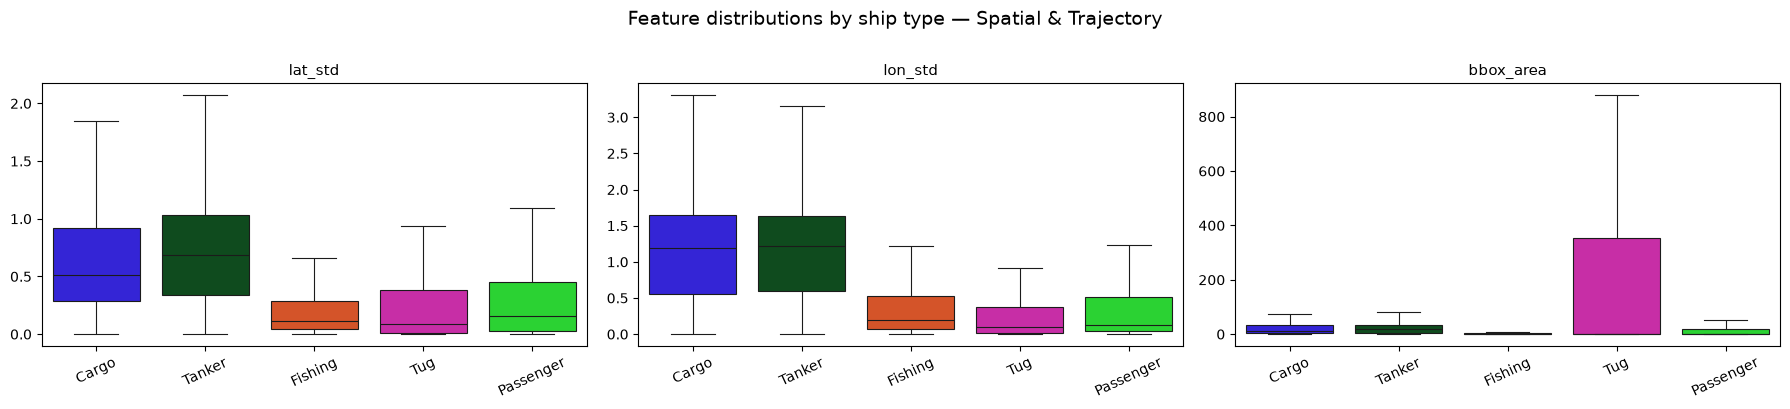

In [27]:
plot_feature_group(pddf, "Spatial & Trajectory", feature_groups["Spatial & Trajectory"])

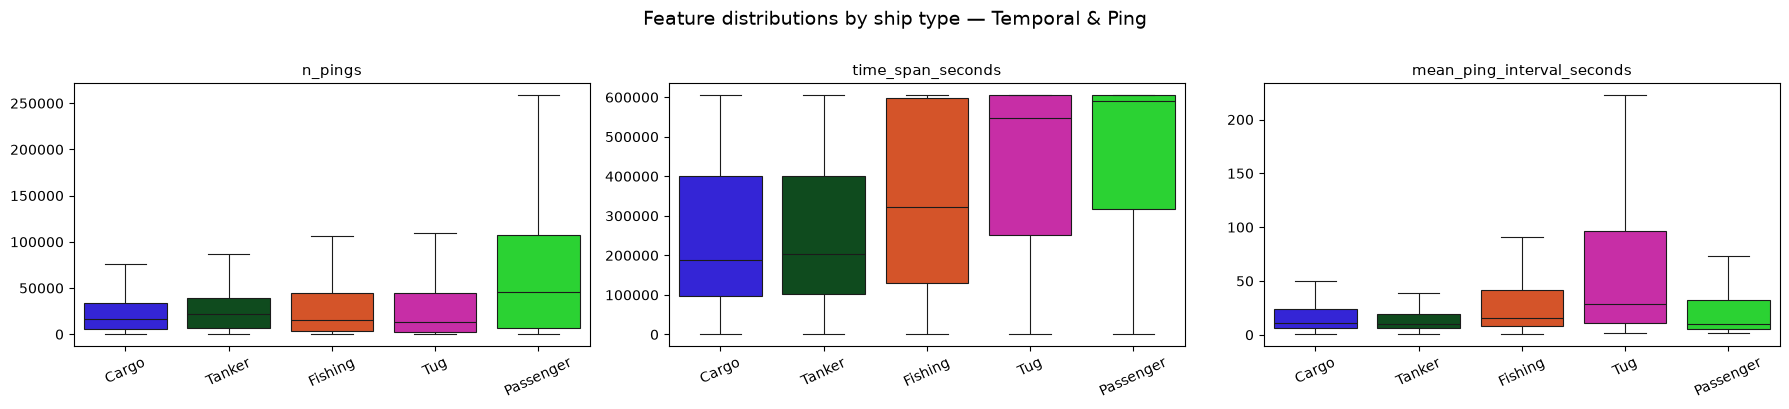

In [28]:
plot_feature_group(pddf, "Temporal & Ping", feature_groups["Temporal & Ping"])

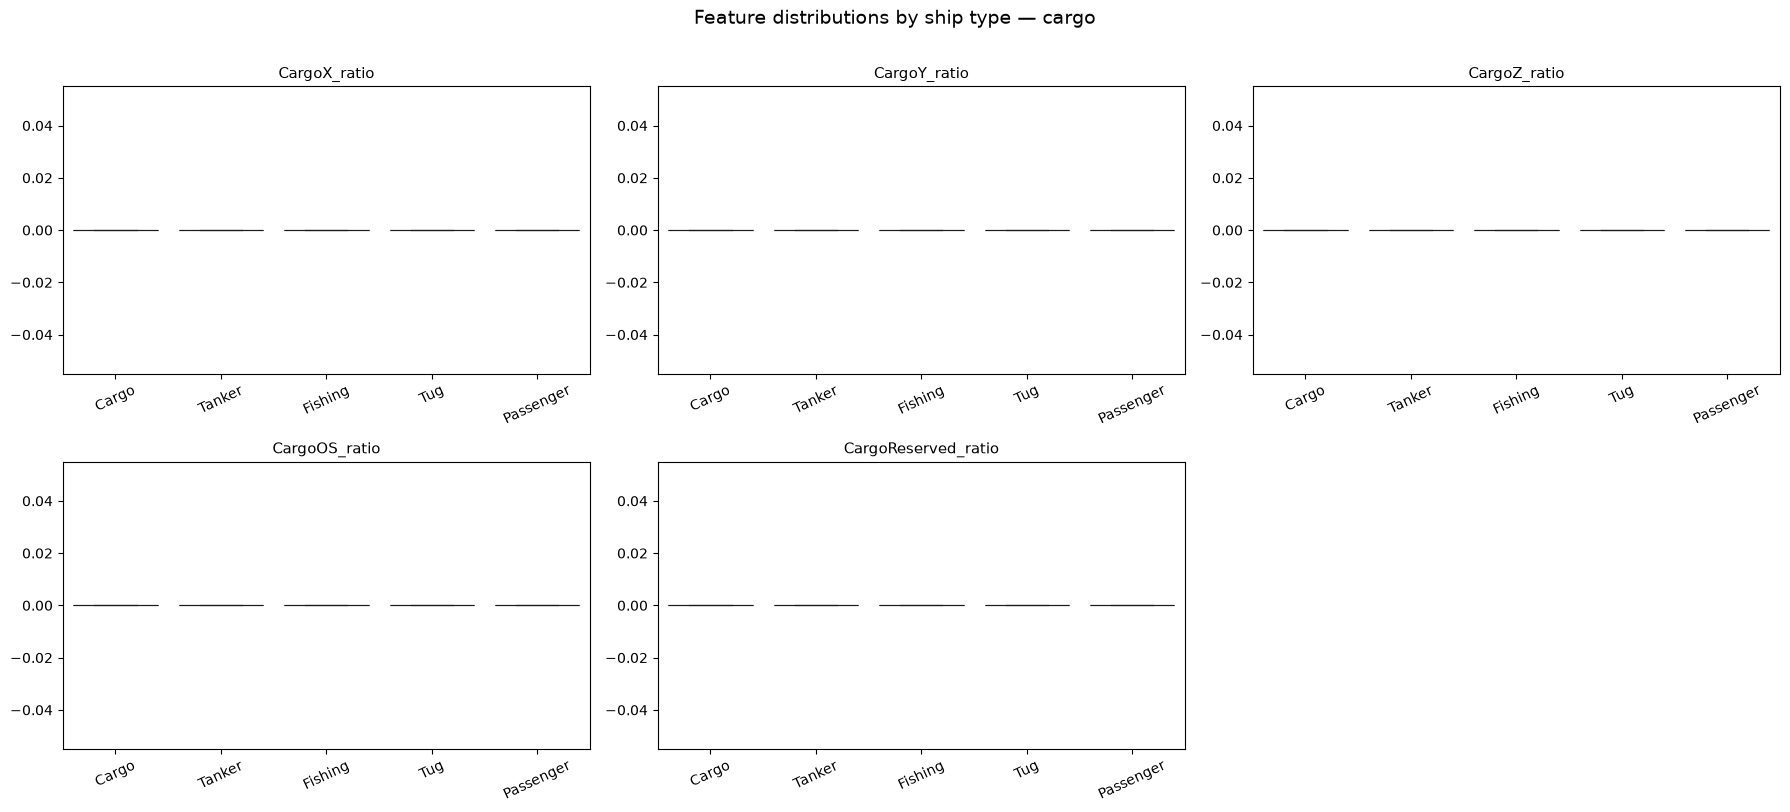

In [29]:
plot_feature_group(pddf, "cargo", ["Cargo Type", "CargoX_ratio", "CargoY_ratio", "CargoZ_ratio", "CargoOS_ratio", "CargoReserved_ratio"])

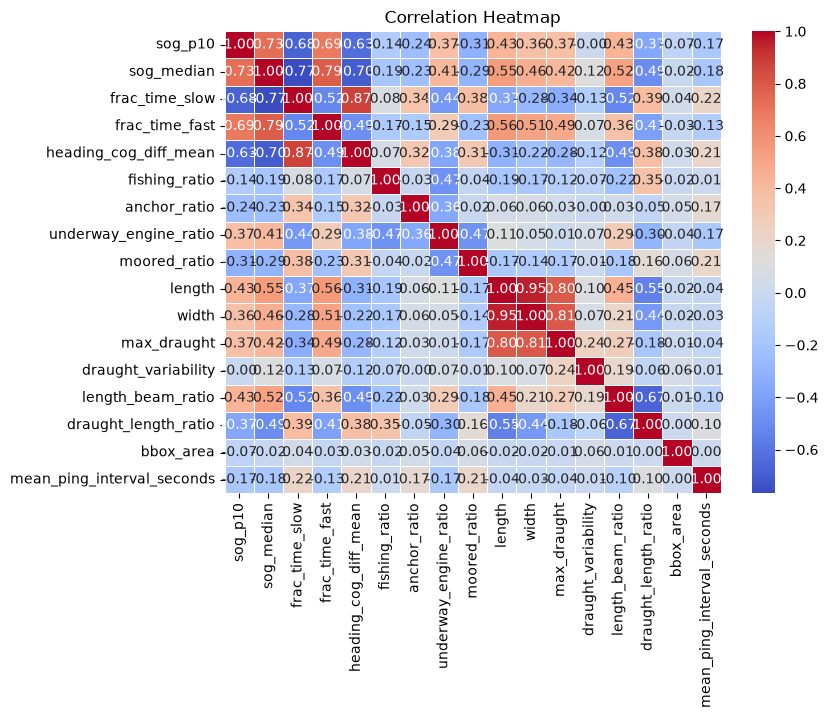

In [36]:
features = [
    "sog_p10",
    "sog_median",
    "frac_time_slow",
    "frac_time_fast",
    "heading_cog_diff_mean",
    "fishing_ratio",
    "anchor_ratio",
    "underway_engine_ratio",
    "moored_ratio",
    "length",
    "width",
    "max_draught",
    "draught_variability",
    "length_beam_ratio",
    "draught_length_ratio",
    "bbox_area",
    "mean_ping_interval_seconds",
]
matrix = pddf[features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
)
plt.title("Correlation Heatmap")
plt.show()

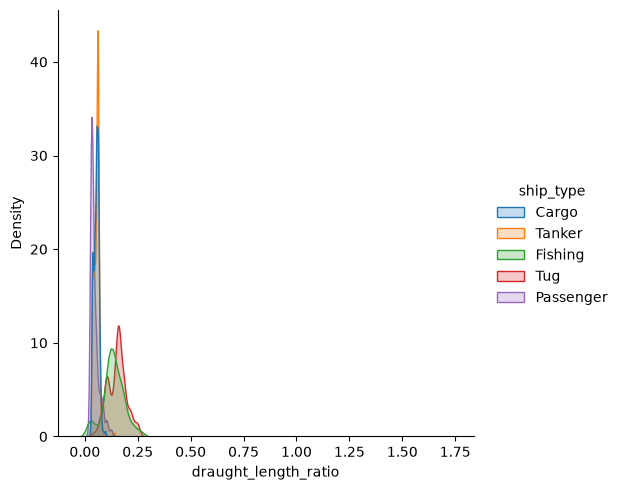

In [ ]:
# 'common_norm=False' normalizes each class independently so you can see relative shapes
sns.displot(data=pddf, x="draught_length_ratio", hue="ship_type", kind="kde", fill=True, common_norm=False)
plt.show()


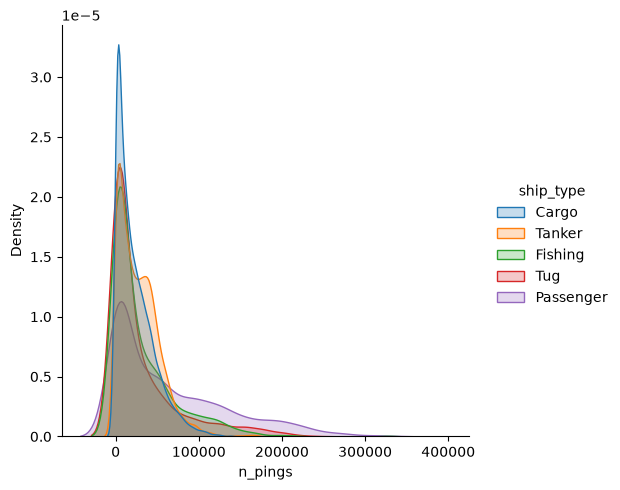

In [ ]:
# 'common_norm=False' normalizes each class independently so you can see relative shapes
sns.displot(data=pddf, x="n_pings", hue="ship_type", kind="kde", fill=True, common_norm=False)
plt.show()

: 